In [25]:
import qft_analysis_pqc as qft
import load_circuits as lc
import compile_circuits as cc
import pprint
from qiskit.qasm3 import loads
import pandas as pd
import csv
import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter

from qiskit_ibm_runtime import QiskitRuntimeService

from importlib import reload


In [61]:
cc = reload(cc)

In [2]:
my_api_key = "cIN4ezzj7vCOgLsAqT52MWFIt9gz0Y96enEy0UN8WrSl"

In [3]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="cIN4ezzj7vCOgLsAqT52MWFIt9gz0Y96enEy0UN8WrSl", 
    overwrite=True
)

In [4]:
# 1. Initialize the IBM Quantum Runtime service
service = QiskitRuntimeService()
backend = service.backend("ibm_boston")
dt = backend.configuration().dt


qiskit_runtime_service.__init__:WARNING:2026-07-15 15:21:39,528: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (flex), the available account instances are: Capgemini. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-15 15:21:39,535: Using instance: Capgemini, plan: flex


## Load DataFrame 

In [5]:
from pathlib import Path

notebook_dir = Path.cwd()
circuit_data = notebook_dir/ "parity_qc_data" / "circuit_data_fo.json.gz"
fowler_data = notebook_dir / "parity_qc_data" / "fowler_qft_default_data.csv"
heavyhex_data = notebook_dir / "parity_qc_data" / "ibm_boston_heavy_hex_free_layouts_dd.csv"
linear_data = notebook_dir / "parity_qc_data" / "linear_twine_qft_default_data.csv" 

In [6]:
circuit_df = qft.process_qft_experiments(circuit_data)

## Compile the Circuits 

### Qiksit Compile 

In [49]:
example_circuit = lc.get_circuit(circuit_df, id_number=80, qft_method='TwineQFTHeavyHex')

In [ ]:
#compile using qiskit compiler 
compiled_circuit = cc.qiskit_compile(example_circuit, backend=backend)

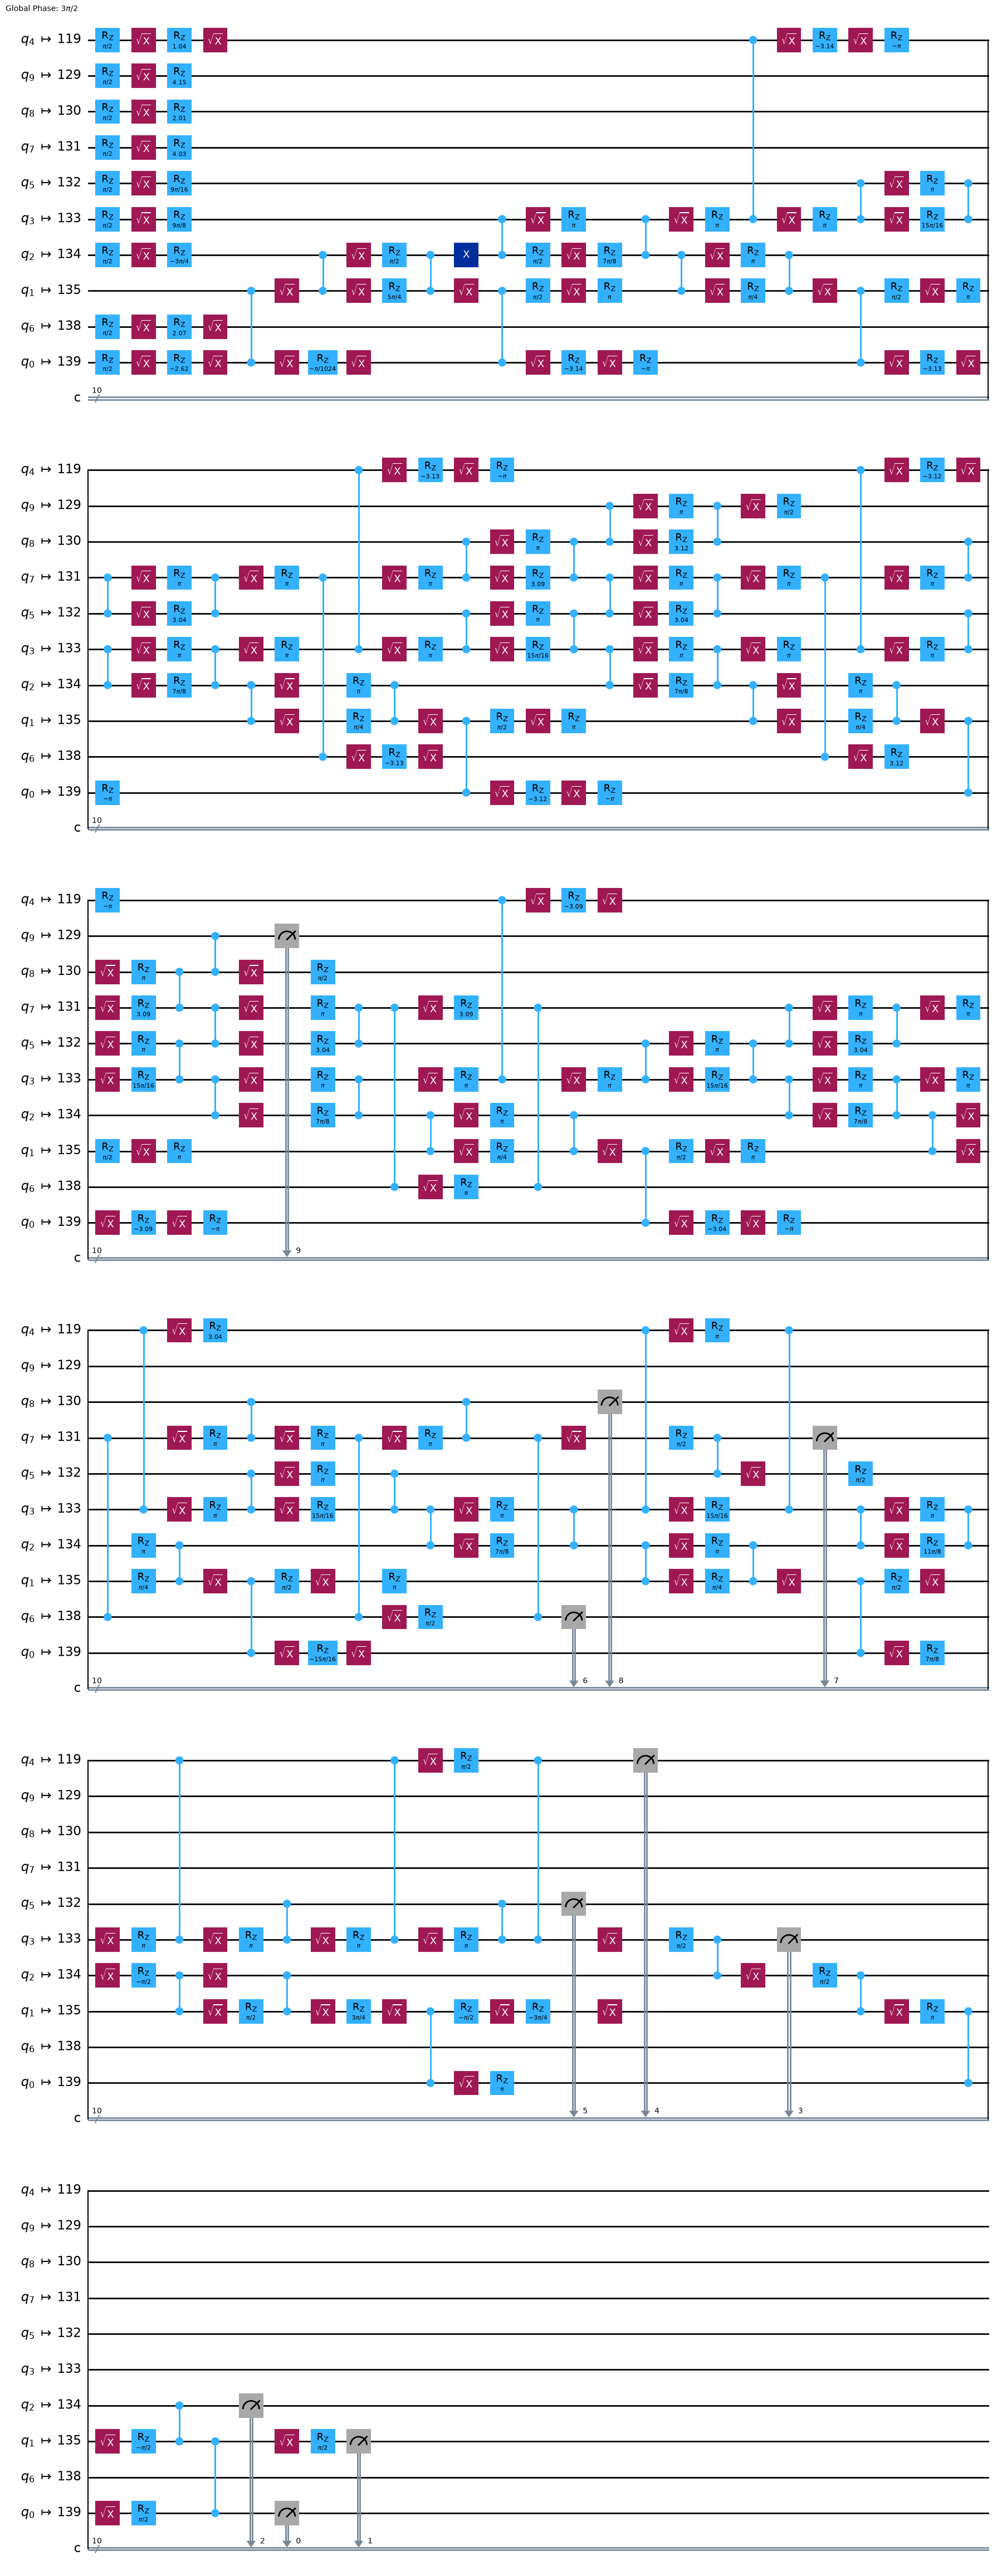

In [51]:

compiled_circuit.draw('mpl')

In [10]:
qiskit_circuit_metrics = cc.get_transpilation_metrics(compiled_circuit, backend=backend, dt=dt)
print(qiskit_circuit_metrics)

{'depth': 15, 'num_2q_gates': 3, 'num_2q_depth': 3}


### Fire Opal Compile 

In [52]:
fo_compiled_circuit = cc.fo_compiler(
    circuits=[example_circuit],
    device_name="ibm_boston",
    credentials={"token": my_api_key},
    initial_layout=None,
    unitary_resynthesis_threshold=4e-5,
)

qiskit_runtime_service._discover_account:WARNING:2026-07-15 15:50:11,802: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-15 15:50:14,664: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (flex), the available account instances are: Capgemini. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-15 15:50:14,666: Using instance: Capgemini, plan: flex


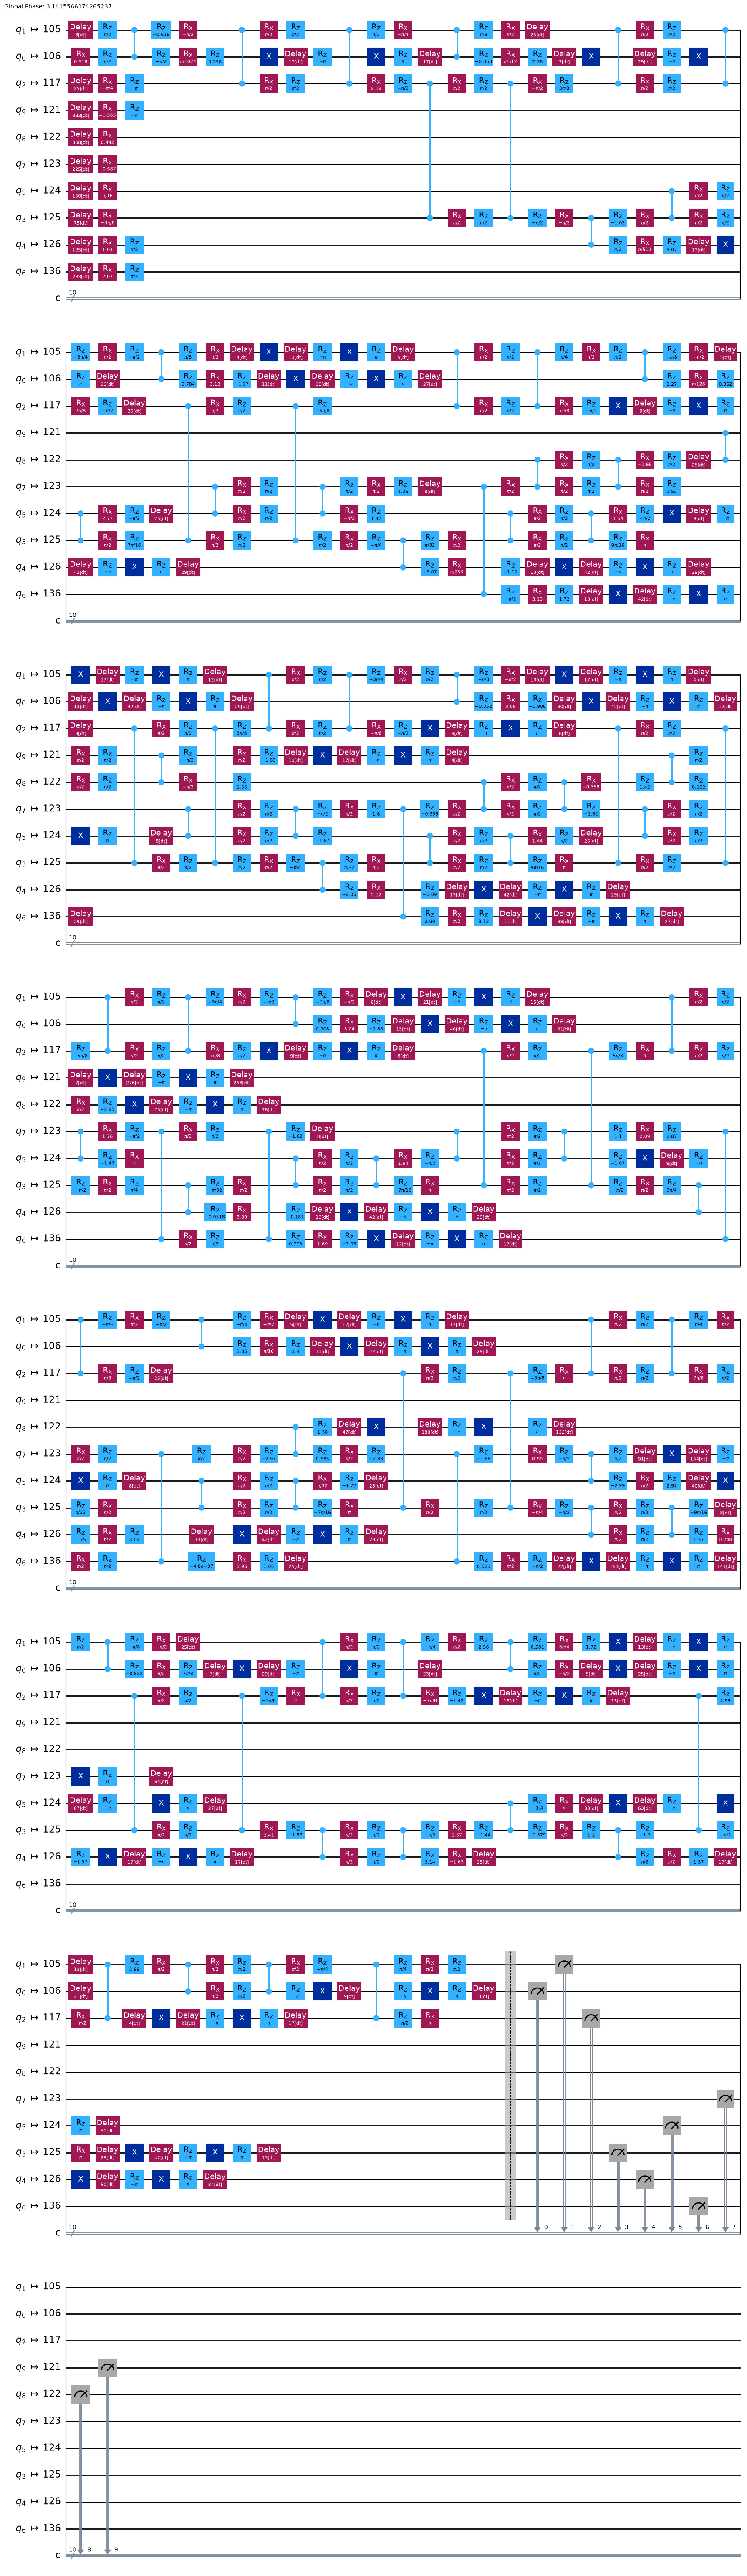

In [53]:
# 1. Turn your string back into a Qiskit circuit object
fo_compiled_circuit = fo_compiled_circuit[0]

# 2. Plot it beautifully
fo_compiled_circuit.draw('mpl')

In [ ]:
fo_compiled_metrics = cc.get_transpilation_metrics(fo_compiled_circuit, backend=backend, dt=dt)


{'depth': 12, 'num_2q_gates': 3, 'num_2q_depth': 4}


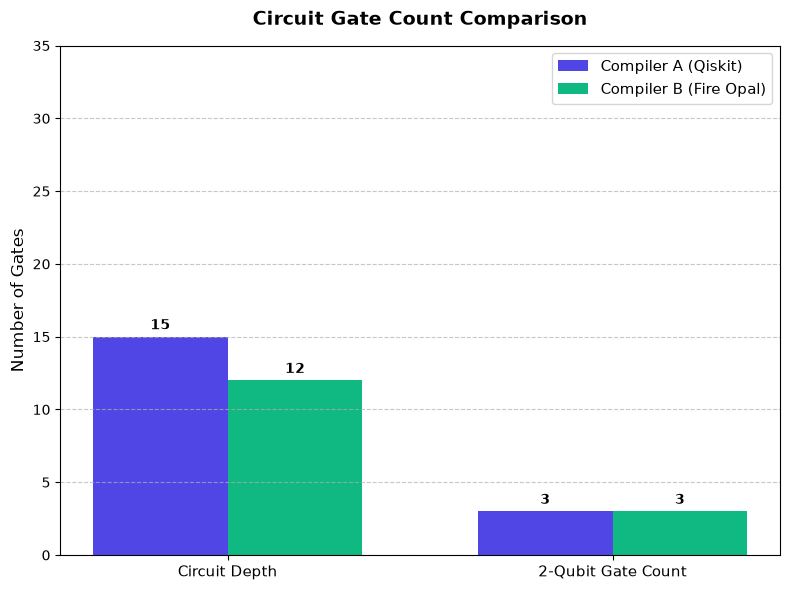

In [14]:

# Extracting the metrics you want to plot
metrics = ['Circuit Depth', '2-Qubit Gate Count']
counts_fo = [fo_compiled_metrics['depth'], fo_compiled_metrics['num_2q_gates']]
counts_qiskit = [qiskit_circuit_metrics['depth'], qiskit_circuit_metrics['num_2q_gates']]


x = np.arange(len(metrics))  # Label locations
width = 0.35  # Width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars for both datasets side-by-side
rects1 = ax.bar(x - width/2, counts_qiskit, width, label='Compiler A (Qiskit)', color='#4F46E5')
rects2 = ax.bar(x + width/2, counts_fo, width, label='Compiler B (Fire Opal)', color='#10B981')

# Add values on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Styling and labels
ax.set_ylabel('Number of Gates', fontsize=12)
ax.set_title('Circuit Gate Count Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, max(counts_fo + counts_qiskit) + 20) # Add padding at the top
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

## Loop over Many Different Circuits to Compile

Want to extract and compile one circuit per number qubits,there are up to 58 qubits per each qft method, only even numbers so want to have 29 circuits per qft method?

In [55]:
qft_methods = circuit_df['qft_method'].unique()
print(qft_methods)

['TwineQFTHeavyHex' 'TwineQFTLinear' 'FowlerQFT']


In [56]:
heavyhex_10th_dict = lc.get_xth_circuits(circuit_df, 'TwineQFTHeavyHex', x=10)
fowler_10th_dict = lc.get_xth_circuits(circuit_df, 'FowlerQFT', x=10)
linear_10th_dict = lc.get_xth_circuits(circuit_df, 'TwineQFTLinear', x=10)


In [57]:
circuit_samples = {
    'TwineQFTHeavyHex': heavyhex_10th_dict,
    'FowlerQFT': fowler_10th_dict,
    'TwineQFTLinear': linear_10th_dict
}

In [63]:
hh_compiled_circuits = cc.compile_multiple_qiskit(heavyhex_10th_dict, backend=backend)



In [64]:
hh_compiled_metrics = {} 
hh_compiled_metrics = {circuit_id: cc.get_transpilation_metrics(circuit, backend=backend, dt=dt) for circuit_id, circuit in hh_compiled_circuits.items()}

In [65]:
hh_compiled_circuits_fo = cc.compile_multiple_fo(
    input_circuits_dict=heavyhex_10th_dict, api_key=my_api_key, device_name="ibm_boston")


qiskit_runtime_service._discover_account:WARNING:2026-07-16 11:37:21,687: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-16 11:37:24,365: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (flex), the available account instances are: Capgemini. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-16 11:37:24,367: Using instance: Capgemini, plan: flex
qiskit_runtime_service._discover_account:WARNING:2026-07-16 11:37:25,402: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-16 11:37:27,638: Instance was not set at service instantiation. Free and trial pla

In [66]:
hh_compiled_metrics_fo = {} 
hh_compiled_metrics_fo = {circuit_id: cc.get_transpilation_metrics(circuit, backend=backend, dt=dt) for circuit_id, circuit in hh_compiled_circuits_fo.items()} 

In [67]:
print(hh_compiled_metrics_fo[2])

{'depth': 12, 'num_2q_gates': 3, 'num_2q_depth': 4}


In [68]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metrics_vs_qubits(
    compiler_a_results, 
    compiler_b_results, 
    metrics_to_plot=None,
    label_a='Compiler A (Qiskit)',
    label_b='Compiler B (Fire Opal)',
    color_a='#4F46E5',
    color_b='#10B981'
):
    """
    Generates individual plots comparing metrics vs. qubit counts for two compilers.
    
    Parameters:
    -----------
    compiler_a_results : dict
        Dict mapping {num_qubits: {'depth': val, 'num_2q_gates': val, ...}}
    compiler_b_results : dict
        Dict mapping {num_qubits: {'depth': val, 'num_2q_gates': val, ...}}
    metrics_to_plot : dict, optional
        A mapping of the metric keys in your data to the labels you want on the Y-axis.
        Defaults to comparing 'depth' and 'num_2q_gates'.
    """
    if metrics_to_plot is None:
        metrics_to_plot = {
            'depth': 'Circuit Depth',
            'num_2q_gates': '2-Qubit Gate Count',
            'num_2q_depth': '2-Qubit Gate Depth'
        }
        
    # 1. Find and sort the common qubit counts to ensure lines plot in the correct order
    common_qubits = sorted(list(set(compiler_a_results.keys()).intersection(compiler_b_results.keys())))
    
    if not common_qubits:
        print("Error: No matching qubit counts found between both result sets.")
        return

    # 2. Generate a separate plot for each metric
    for metric_key, metric_display_name in metrics_to_plot.items():
        # Extract values in the sorted order of qubits
        values_a = [compiler_a_results[q][metric_key] for q in common_qubits]
        values_b = [compiler_b_results[q][metric_key] for q in common_qubits]
        
        # Create the figure
        fig, ax = plt.subplots(figsize=(8, 5))
        
        # Plot lines with markers
        ax.plot(common_qubits, values_a, marker='o', linewidth=2, label=label_a, color=color_a)
        ax.plot(common_qubits, values_b, marker='s', linewidth=2, label=label_b, color=color_b)
        
        # Add labels to individual data points to make them easy to read
        for q, val_a, val_b in zip(common_qubits, values_a, values_b):
            ax.annotate(f'{val_a}', (q, val_a), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color=color_a, fontweight='bold')
            ax.annotate(f'{val_b}', (q, val_b), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color=color_b, fontweight='bold')
        
        # Styling
        ax.set_title(f'Scaling Comparison: {metric_display_name}', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Number of Qubits', fontsize=12)
        ax.set_ylabel(metric_display_name, fontsize=12)
        
        # Ensure x-axis ticks are integers corresponding to actual qubit counts
        ax.set_xticks(common_qubits)
        
        # Dynamic y-axis limit to leave room for the labels on top of the dots
        max_val = max(max(values_a), max(values_b))
        ax.set_ylim(0, max_val * 1.2) 
        
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=11, loc='upper left')
        
        plt.tight_layout()
        plt.show()

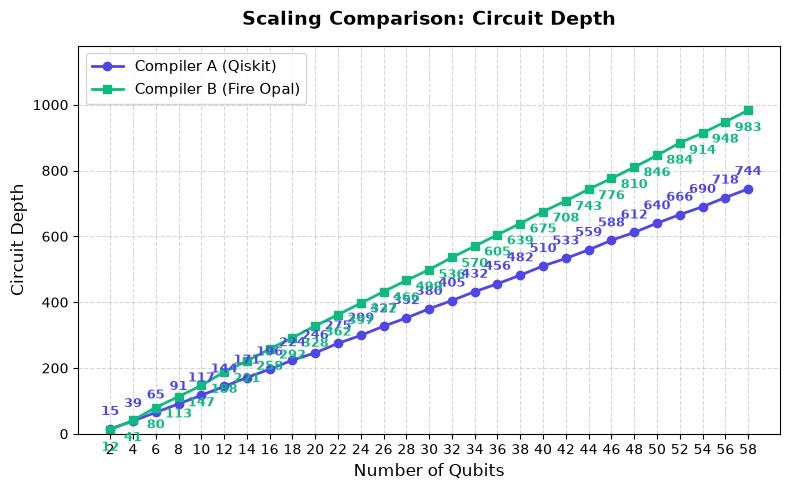

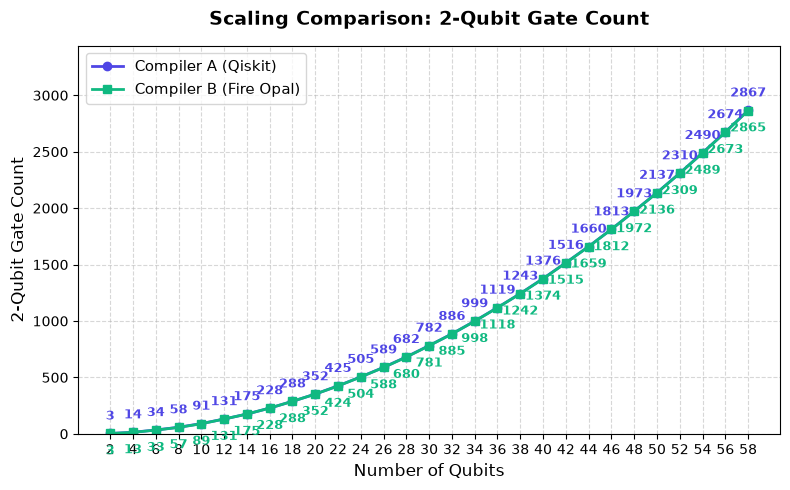

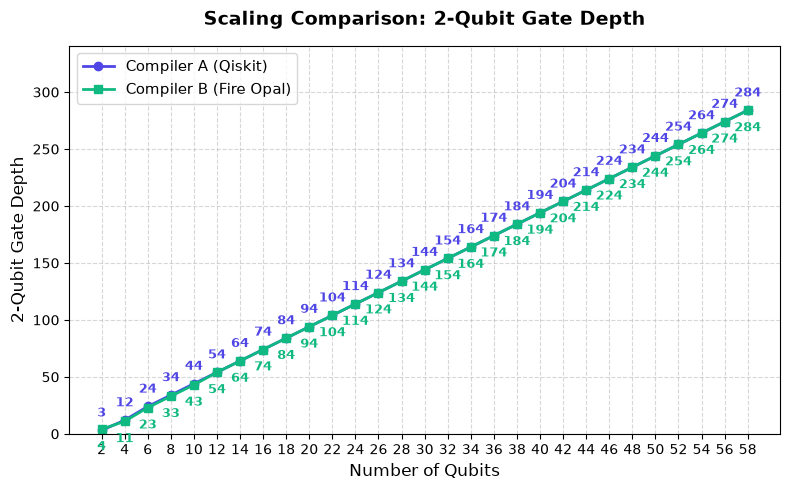

In [69]:
# Run the function
plot_metrics_vs_qubits(hh_compiled_metrics, hh_compiled_metrics_fo)

In [70]:
fowler_compiled_circuits = cc.compile_multiple_qiskit(fowler_10th_dict, backend=backend)


In [71]:
fowler_qiskit_metrics = {}
fowler_qiskit_metrics = {circuit_id: cc.get_transpilation_metrics(circuit, backend=backend, dt=dt) for circuit_id, circuit in fowler_compiled_circuits.items()}

In [72]:
fowler_compiled_circuits_fo = cc.compile_multiple_fo(
    input_circuits_dict=fowler_10th_dict, api_key=my_api_key, device_name="ibm_boston")

qiskit_runtime_service._discover_account:WARNING:2026-07-16 11:43:21,892: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-16 11:43:24,258: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (flex), the available account instances are: Capgemini. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-16 11:43:24,260: Using instance: Capgemini, plan: flex
qiskit_runtime_service._discover_account:WARNING:2026-07-16 11:43:25,630: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-16 11:43:27,983: Instance was not set at service instantiation. Free and trial pla

In [73]:
fowler_compiled_metrics_fo = {}
fowler_compiled_metrics_fo = {circuit_id: cc.get_transpilation_metrics(circuit, backend=backend, dt=dt) for circuit_id, circuit in fowler_compiled_circuits_fo.items()}

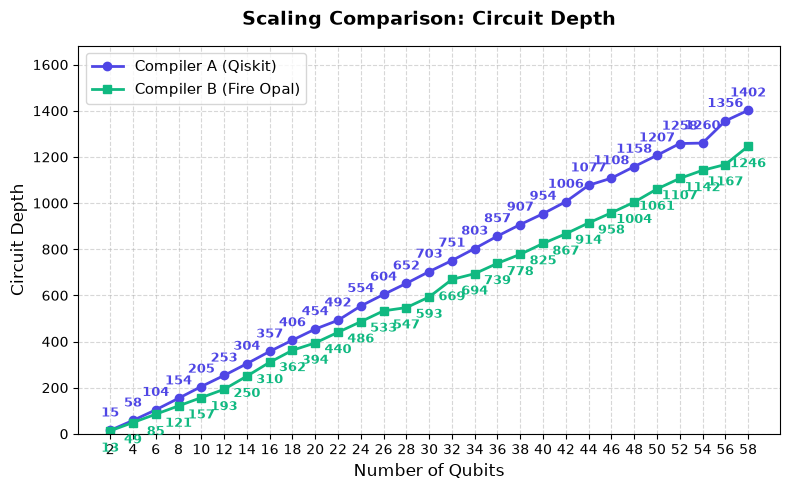

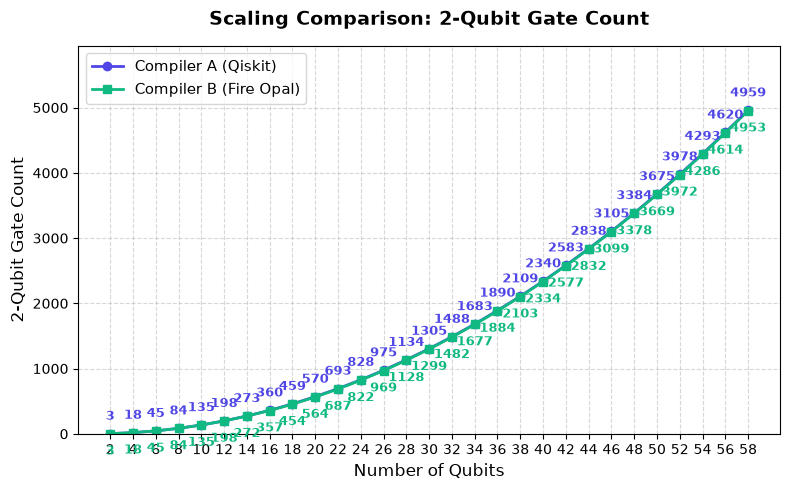

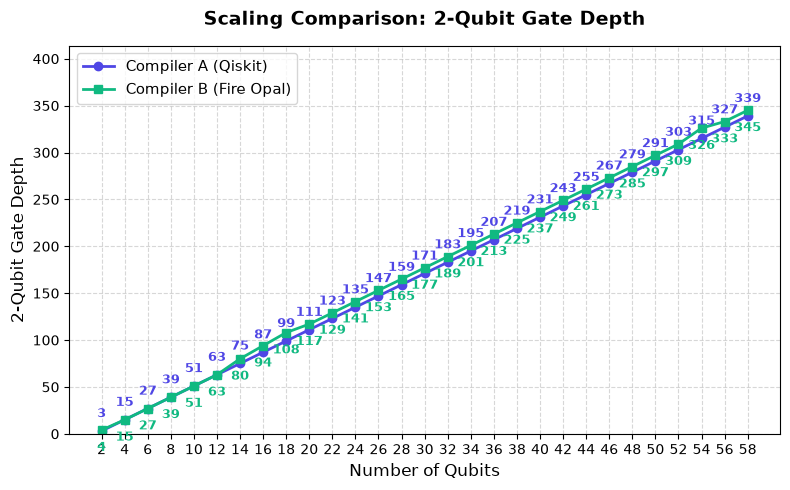

In [74]:

plot_metrics_vs_qubits(fowler_qiskit_metrics, fowler_compiled_metrics_fo)

In [75]:
linear_compiled_circuits = cc.compile_multiple_qiskit(linear_10th_dict, backend=backend)

In [77]:
linear_compiled_metrics = {}
linear_compiled_metrics = {circuit_id: cc.get_transpilation_metrics(circuit, backend=backend, dt=dt) for circuit_id, circuit in linear_compiled_circuits.items()}

In [78]:
linear_compiled_circuits_fo = cc.compile_multiple_fo(
    input_circuits_dict=linear_10th_dict, api_key=my_api_key, device_name="ibm_boston")

qiskit_runtime_service._discover_account:WARNING:2026-07-16 12:04:44,291: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-16 12:04:47,182: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (flex), the available account instances are: Capgemini. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-16 12:04:47,184: Using instance: Capgemini, plan: flex
qiskit_runtime_service._discover_account:WARNING:2026-07-16 12:04:48,490: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-16 12:04:50,482: Instance was not set at service instantiation. Free and trial pla

In [79]:
linear_compiled_metrics_fo = {}
linear_compiled_metrics_fo = {circuit_id: cc.get_transpilation_metrics(circuit, backend=backend, dt=dt) for circuit_id, circuit in linear_compiled_circuits_fo.items()}

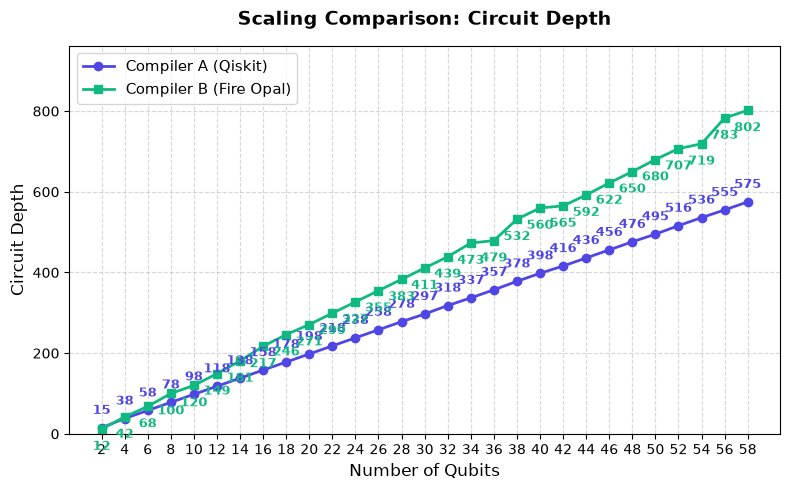

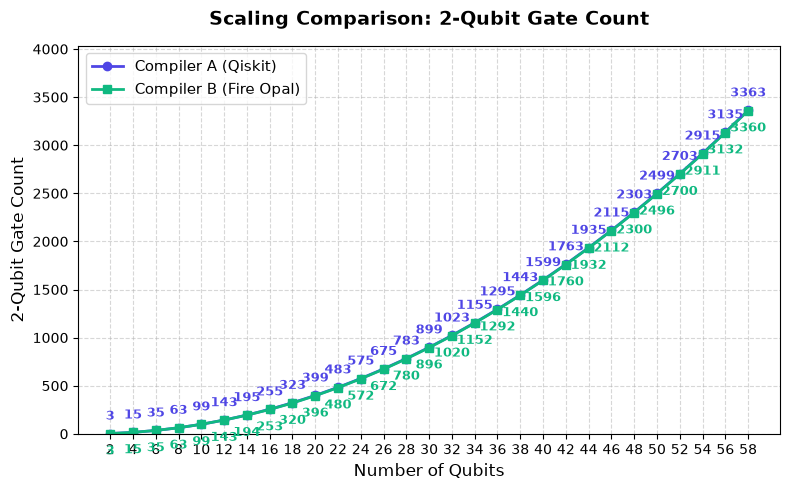

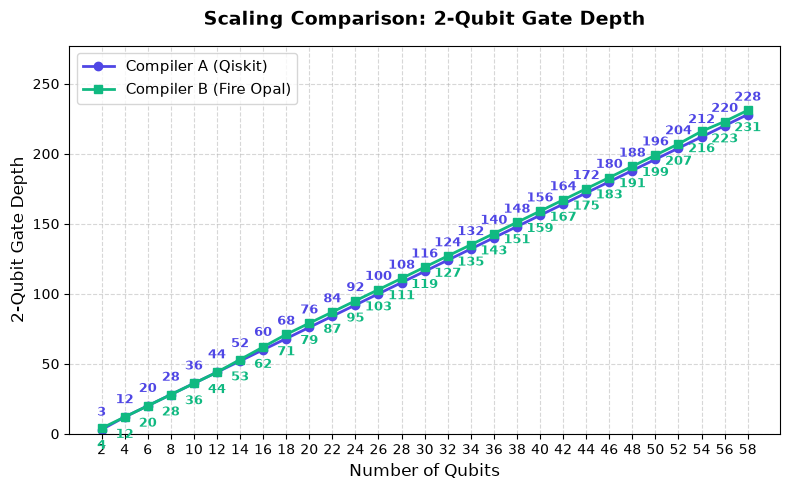

In [80]:
plot_metrics_vs_qubits(linear_compiled_metrics, linear_compiled_metrics_fo)